<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS5: Estimacion espectral: ancho de banda de señales reales

## Estudiante: Mercedes López Gil Dillon

En el siguiente trabajo práctico, utilizaremos señales ya dadas de distinto tipo, y buscaremos realizar la estimación de la densidad espectral de potencia de cada señal mediante alguno de los métodos vistos en clase, en este caso usaremos el metodo de Welch. Teniendo esto, realizaremos una estimación del ancho de banda de cada señal.

Para calcular el espectro con el metodo de Welch, debe elegirse un nperseg, el cual elegiremos analizando visualmente el grafico para poder estimar el valor de este.

¿Por qué se hace esto?
El nperseg controla el trade-off entre resolución en frecuencia y resolución en tiempo:

A un nperseg grande, hay más resolución en frecuencia (podés distinguir componentes cercanas), pero cada segmento abarca más tiempo y el estimado es menos estable (que se traduce en más ruido).

A un nperseg chico, el estimado es más suave y estable (menos ruido), pero perdés detalle en frecuencia.

Es decir, a mayor nperseg disminuye el sesgo pero aumenta la varianza y viceversa.

Para elegirlo gráficamente, graficamos el PSD con distintos valores de nperseg y elegimos el más chico que aún permita ver claramente los picos que nos interesan. 

Por otro lado, para calcular el ancho de banda, utilizaremos el siguiente criterio:

Para señales pasabajos, buscaremos el punto en el cual la potencia desde 0 hasta ese punto es del 98% con respecto a la potencia total, tomando este como ancho de banda. Toda la señal que queda fuera de este ancho de banda, lo tomaremos como el ruido que quedó y no pudo ser filtrado.

En el caso de señales pasabanda, haremos algo parecido, buscaremos nuevamente el ancho de banda que contenga al 98% de la potencia, pero siempre tomando desde dos puntos cuya densidad de potencia es la misma (es decir, buscamos dos puntos con igual densidad de potencia donde entre estos se encuetre el 98% del total de potencia de mi señal).

Es importante aclarar que al ser las señales discretas, por lo general no habrá un punto exacto en el que se encuentre el 98% de la potencia, por lo que tomaremos el primer punto en el que la potencia de el ancho de banda tomado sea de 98% o más.

Las señales a analizar los las siguientes: un ecg sin ruido, un ecg con ruido, un ppg sin ruido, un ppg con ruido y 3 archivos .wav.

In [79]:
#Importamos librerias

import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio

import os

## ECG sin ruido

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\4266854991.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


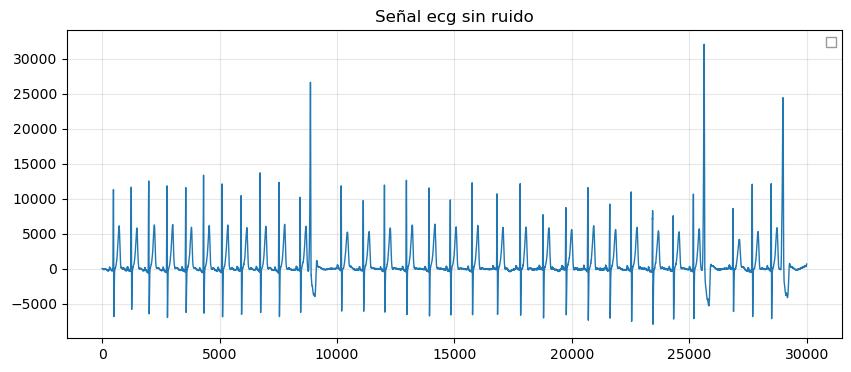

In [80]:
fs_ecg = 1000 # Hz . Dato de consigna

#importamos la señal

carpeta_script_ecg = os.getcwd()

ruta_archivo_ecg = os.path.join(carpeta_script_ecg, 'ecg_sin_ruido.npy')

ecg_one_lead = np.load(ruta_archivo_ecg)

N_ecg = len(ecg_one_lead)

ecg = np.reshape(ecg_one_lead , (1, N_ecg))




plt.figure(figsize=(10, 4))
plt.plot(ecg[0,:], linewidth=1, linestyle='-', label='')
plt.title('Señal ecg sin ruido')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

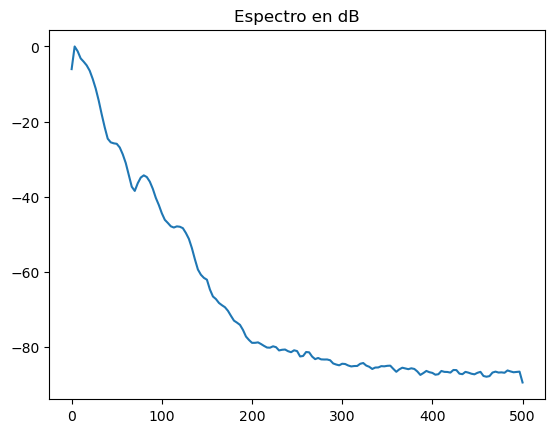

In [81]:

nperseg = 300


#espectroWelch = sig.welch(ecg[0, :], fs=fs_ecg, nperseg=int(N/3))
espectroWelch = sig.welch(ecg[0,:] - np.mean(ecg[0,:]), fs=fs_ecg, nperseg=nperseg)


f, Pxx = espectroWelch

Pxx_max = np.max(Pxx)
Pxx_escalado = Pxx/Pxx_max

Pxx_db= 10 * np.log10(np.abs(Pxx_escalado))

plt.figure()
plt.plot(f, Pxx_db)
plt.title('Espectro en dB')
plt.show()

En este caso, la señal tiene forma de pasabajos, por lo que experimentalmente se calculó el valor en que la potencia sería del 98%.

In [82]:
area = np.sum(Pxx[f <= 30])
area_tot = np.sum(Pxx)
Pxx_porcentaje = area/area_tot
print(Pxx_porcentaje)

0.9889522682534928


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando el punto donde termina el ancho de banda.

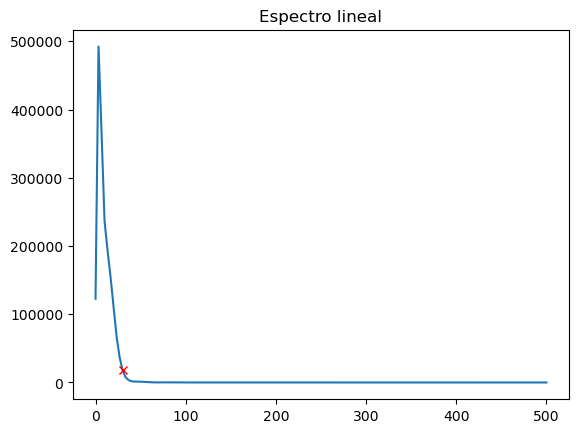

In [83]:
plt.plot(f, Pxx)
idx1 = np.argmin(np.abs(f - 30))
plt.plot(f[idx1], Pxx[idx1], 'rx')
plt.title('Espectro lineal')
plt.show()

## ECG con ruido

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\3662581776.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


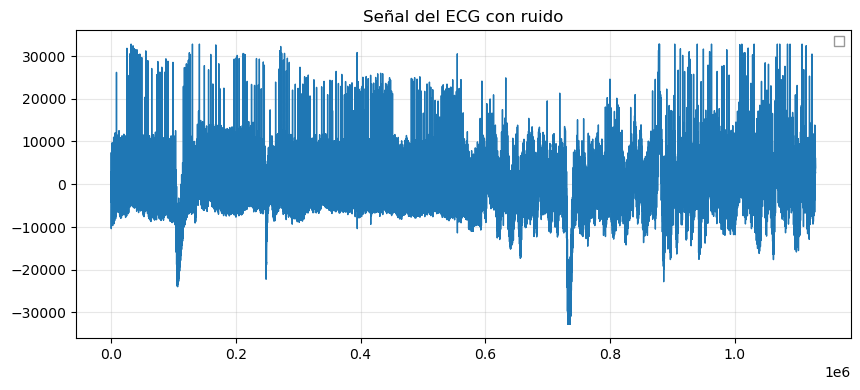

In [84]:
fs_ecg_cr = 1000 #fijarse cual es en realidad el fs para el ecg con ruido


carpeta_script_ecg_cr = os.getcwd()
ruta_archivo_ecg_cr = os.path.join(carpeta_script_ecg_cr, 'ECG_TP4.mat')
datos = sio.loadmat(ruta_archivo_ecg_cr)
ecg_one_lead_cr = datos['ecg_lead'].flatten()


N_ecg_cr = len(ecg_one_lead_cr)

ecg_cr = np.reshape(ecg_one_lead_cr , (1, N_ecg_cr))


plt.figure(figsize=(10, 4))
plt.plot(ecg_cr[0,:], linewidth=1, linestyle='-', label='')
plt.title('Señal del ECG con ruido')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

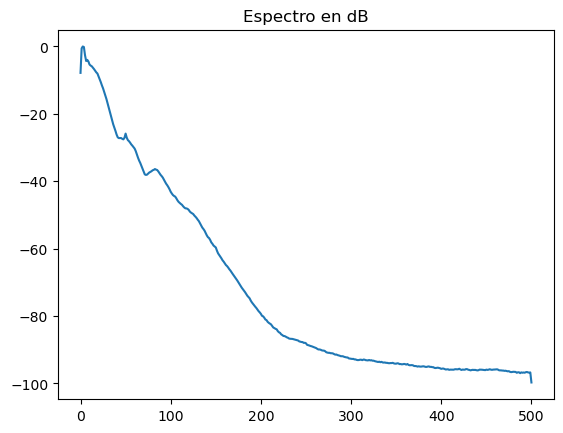

In [85]:
nperseg_cr = 800

espectroWelch_cr = sig.welch(ecg_cr[0,:] - np.mean(ecg_cr[0,:]), fs=fs_ecg_cr, nperseg=nperseg_cr)

f_cr, Pxx_cr = espectroWelch_cr

Pxx_max_cr = np.max(Pxx_cr)
Pxx_cr_escalado = Pxx_cr/Pxx_max_cr

Pxx_db_cr= 10 * np.log10(np.abs(Pxx_cr_escalado))

plt.figure()
plt.plot(f_cr, Pxx_db_cr)
plt.title('Espectro en dB')
plt.show()

In [86]:
area_cr = np.sum(Pxx_cr[f_cr <= 28])
area_tot_cr = np.sum(Pxx_cr)
Pxx_cr_porcentaje = area_cr/area_tot_cr
print(Pxx_cr_porcentaje)

0.9804949019532693


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando el punto donde termina el ancho de banda.

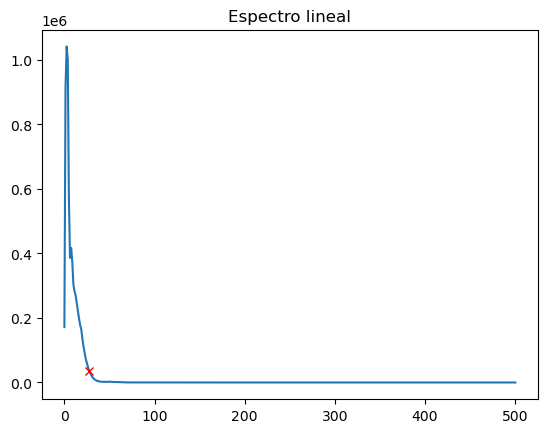

In [87]:
plt.plot(f_cr, Pxx_cr)
idx1 = np.argmin(np.abs(f_cr - 28))
plt.plot(f_cr[idx1], Pxx_cr[idx1], 'rx')
plt.title('Espectro lineal')
plt.show()

## PPG sin ruido

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\255055550.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


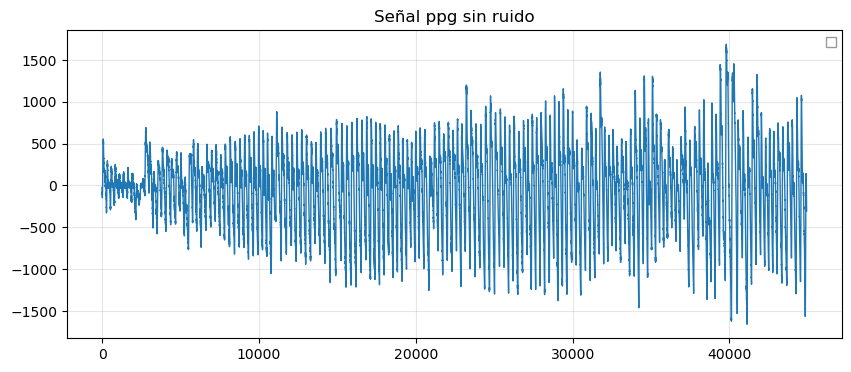

In [88]:
fs_ppg = 400 # Hz

carpeta_script_ppg = os.getcwd()
ruta_archivo_ppg = os.path.join(carpeta_script_ppg, "ppg_sin_ruido.npy")
ppg_one_lead = np.load(ruta_archivo_ppg)

N_ppg = len(ppg_one_lead)

ppg = np.reshape(ppg_one_lead , (1, N_ppg))


plt.figure(figsize=(10, 4))
plt.plot(ppg[0,:], linewidth=1, linestyle='-', label='')
plt.title('Señal ppg sin ruido')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

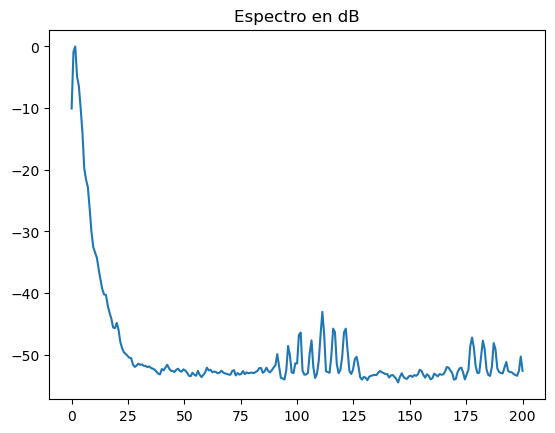

In [89]:
nperseg_ppg= 500

espectroWelch_ppg = sig.welch(ppg[0,:] - np.mean(ppg[0,:]), fs=fs_ppg, nperseg= nperseg_ppg)

f_ppg, Pxx_ppg = espectroWelch_ppg


Pxx_max_ppg = np.max(Pxx_ppg)
Pxx_ppg_escalado = Pxx_ppg/Pxx_max_ppg

Pxx_ppg_db= 10 * np.log10(np.abs(Pxx_ppg_escalado))

plt.figure()
plt.plot(f_ppg, Pxx_ppg_db)
plt.title('Espectro en dB')
plt.show()

In [90]:
area_ppg = np.sum(Pxx_ppg[f_ppg <= 5])
area_tot_ppg = np.sum(Pxx_ppg)
Pxx_ppg_porcentaje = area_ppg/area_tot_ppg
print(Pxx_ppg_porcentaje)

0.9886735743655823


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando el punto donde termina el ancho de banda.

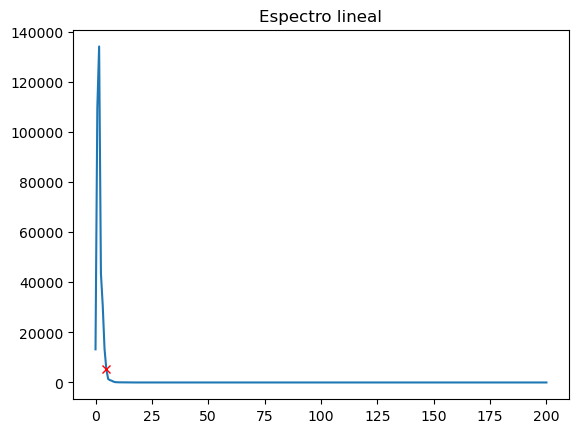

In [91]:
plt.plot(f_ppg, Pxx_ppg)
idx1 = np.argmin(np.abs(f_ppg - 5))
plt.plot(f_ppg[idx1], Pxx_ppg[idx1], 'rx')
plt.title('Espectro lineal')
plt.show()

## PPG con ruido

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\2649025574.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


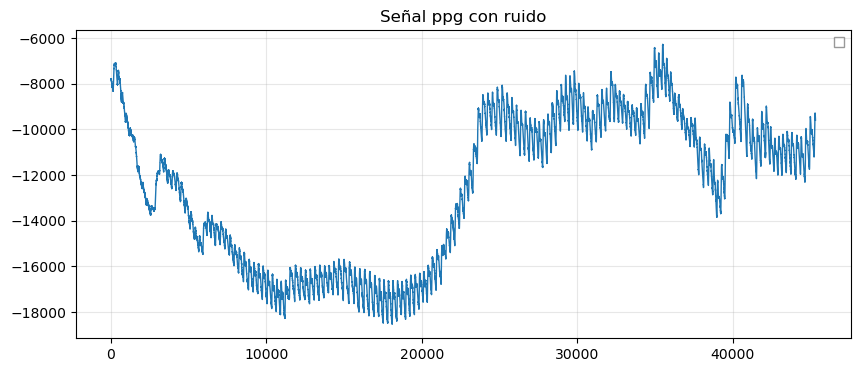

In [92]:
import pandas as pd

fs_ppg_cr = 400 #Hz #fijarse cual es el verdadero valor de fs para el ppg con ruido

carpeta_script_ppg_cr = os.getcwd()
ruta_archivo_ppg_cr = os.path.join(carpeta_script_ppg_cr, 'PPG.csv')

ppg_data = pd.read_csv(ruta_archivo_ppg_cr, header=None)
ppg_one_lead_cr = ppg_data[0].values

N_ppg_cr = len(ppg_one_lead_cr)

ppg_cr = np.reshape(ppg_one_lead_cr , (1, N_ppg_cr))


plt.figure(figsize=(10, 4))
plt.plot(ppg_cr[0,:], linewidth=1, linestyle='-', label='')
plt.title('Señal ppg con ruido')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

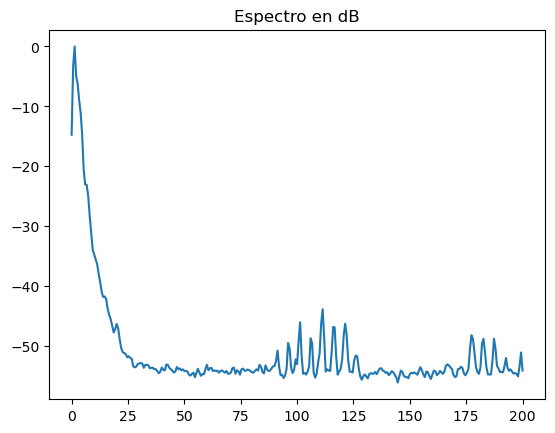

In [93]:
nperseg_ppg_cr = 600

espectroWelch_ppg_cr = sig.welch(ppg_cr[0,:] - np.mean(ppg_cr[0,:]), fs=fs_ppg_cr, nperseg=nperseg_ppg_cr)

f_ppg_cr, Pxx_ppg_cr = espectroWelch_ppg_cr

Pxx_max_ppg_cr = np.max(Pxx_ppg_cr)
Pxx_ppg_cr_escalado = Pxx_ppg_cr/Pxx_max_ppg_cr

Pxx_ppg_cr_db= 10 * np.log10(np.abs(Pxx_ppg_cr_escalado))

plt.figure()
plt.plot(f_ppg_cr, Pxx_ppg_cr_db)
plt.title('Espectro en dB')
plt.show()

In [94]:
area_ppg_cr = np.sum(Pxx_ppg_cr[f_ppg_cr <= 5])
area_tot_ppg_cr = np.sum(Pxx_ppg_cr)
Pxx_ppg_cr_porcentaje = area_ppg_cr/area_tot_ppg_cr
print(Pxx_ppg_cr_porcentaje)

0.9880734542959841


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando el punto donde termina el ancho de banda.

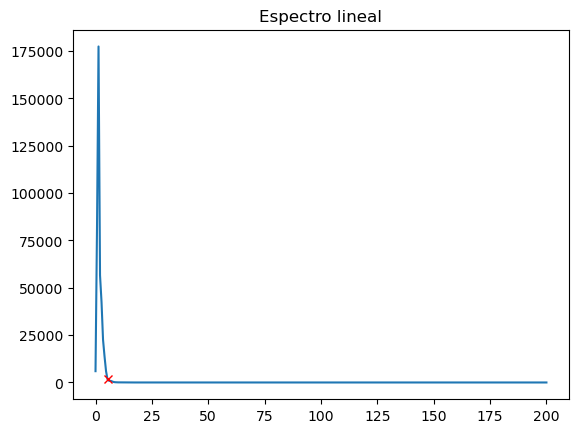

In [95]:
plt.plot(f_ppg_cr, Pxx_ppg_cr)
idx1 = np.argmin(np.abs(f_ppg_cr - 5))
plt.plot(f_ppg_cr[idx1], Pxx_ppg_cr[idx1], 'rx')
plt.title('Espectro lineal')
plt.show()

## Prueba psd

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\3320187900.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


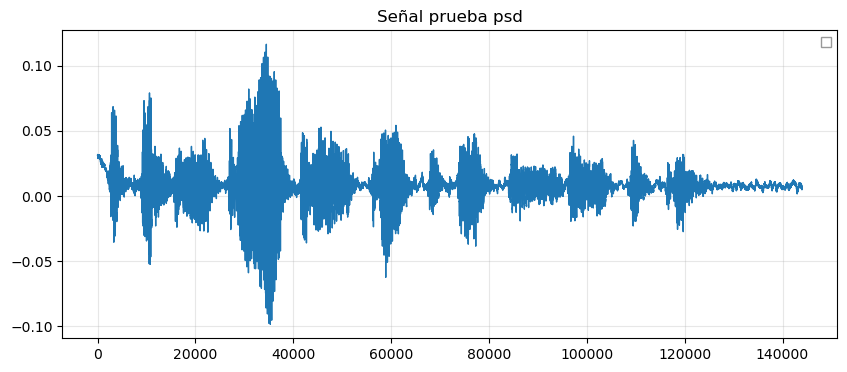

In [96]:
carpeta_script_wav = os.getcwd()
ruta_archivo_wav = os.path.join(carpeta_script_wav, 'prueba psd.wav')
fs_audio_wav, wav_data = sio.wavfile.read(ruta_archivo_wav)

N_wav = len(wav_data)

wav_data_rotado = np.reshape(wav_data , (1, N_wav))


plt.figure(figsize=(10, 4))
plt.plot(wav_data, linewidth=1, linestyle='-', label='')
plt.title('Señal prueba psd')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

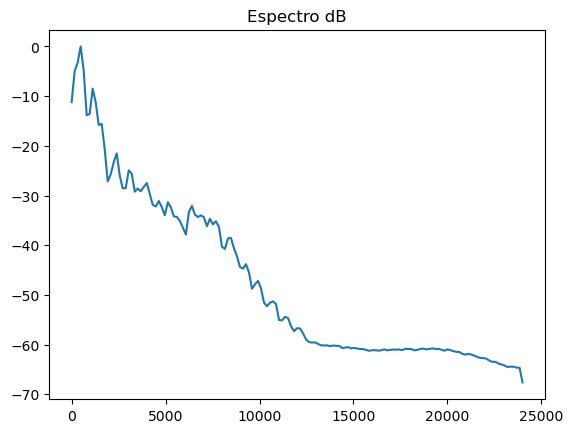

In [98]:
nperseg_wav = 300

espectroWelch_wav = sig.welch(wav_data_rotado[0,:] - np.mean(wav_data_rotado[0,:]), fs=fs_audio_wav, nperseg=nperseg_wav)

f_wav, Pxx_wav = espectroWelch_wav

Pxx_max_wav = np.max(Pxx_wav)
Pxx_wav_escalado = Pxx_wav/Pxx_max_wav

Pxx_wav_db= 10 * np.log10(np.abs(Pxx_wav_escalado))

plt.figure()
plt.plot(f_wav, Pxx_wav_db)
plt.title('Espectro dB')
plt.show()

In [99]:
area_wav = np.sum(Pxx_wav[f_wav <= 640])
area_tot_wav = np.sum(Pxx_wav)
Pxx_wav_porcentaje = area_wav/area_tot_wav
print(Pxx_wav_porcentaje)

0.84228945


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando el punto donde termina el ancho de banda.

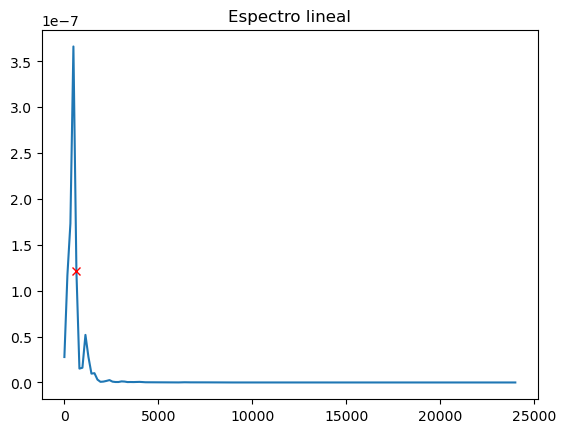

In [100]:
plt.plot(f_wav, Pxx_wav)
idx1 = np.argmin(np.abs(f_wav - 640))
plt.plot(f_wav[idx1], Pxx_wav[idx1], 'rx')
plt.title('Espectro lineal')
plt.show()

## Silbido

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\3309335398.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


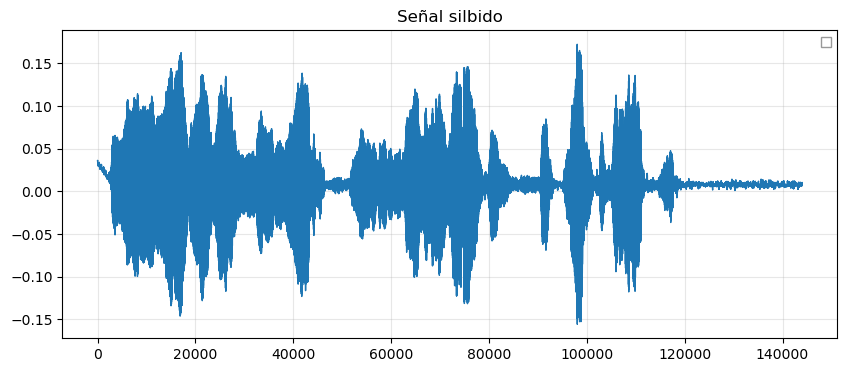

In [101]:
carpeta_script_wav = os.getcwd()

ruta_archivo_wav = os.path.join(carpeta_script_wav, 'silbido.wav')

fs_audio_wav, wav_data = sio.wavfile.read(ruta_archivo_wav)


N_wav = len(wav_data)

wav_data_rotado = np.reshape(wav_data , (1, N_wav))


plt.figure(figsize=(10, 4))
plt.plot(wav_data, linewidth=1, linestyle='-', label='')
plt.title('Señal silbido')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

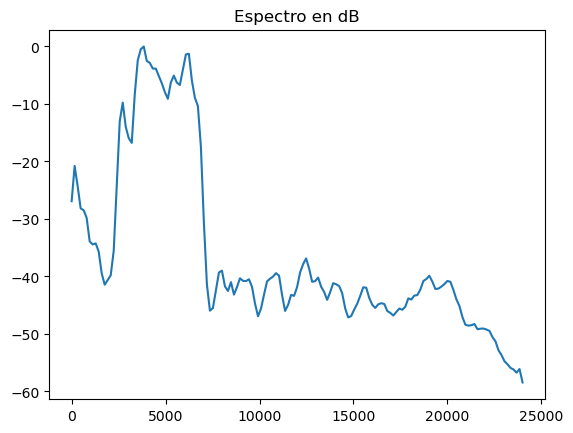

In [102]:
nperseg_wav = 300

espectroWelch_wav = sig.welch(wav_data_rotado[0,:] - np.mean(wav_data_rotado[0,:]), fs=fs_audio_wav, nperseg=nperseg_wav)

f_wav, Pxx_wav = espectroWelch_wav

Pxx_max_wav = np.max(Pxx_wav)
Pxx_wav_escalado = Pxx_wav/Pxx_max_wav

Pxx_wav_db= 10 * np.log10(np.abs(Pxx_wav_escalado))

plt.figure()
plt.plot(f_wav, Pxx_wav_db)
plt.title('Espectro en dB')
plt.show()

In [103]:
area_wav = np.sum(Pxx_wav[f_wav <= 6800]) - np.sum(Pxx_wav[f_wav <= 2719])
area_tot_wav = np.sum(Pxx_wav)
Pxx_wav_porcentaje = area_wav/area_tot_wav
print(Pxx_wav_porcentaje)

0.98905885


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando los puntos donde comienza y termina el ancho de banda.

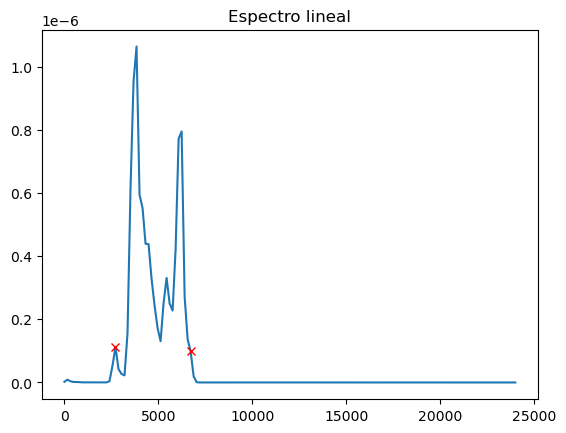

In [104]:
plt.plot(f_wav, Pxx_wav)
idx1 = np.argmin(np.abs(f_wav - 6800))
idx2 = np.argmin(np.abs(f_wav - 2719))
plt.plot(f_wav[idx1], Pxx_wav[idx1], 'rx')
plt.plot(f_wav[idx2], Pxx_wav[idx2], 'rx')
plt.title('Espectro lineal')
plt.show()

## La cucaracha

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\2945043205.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)


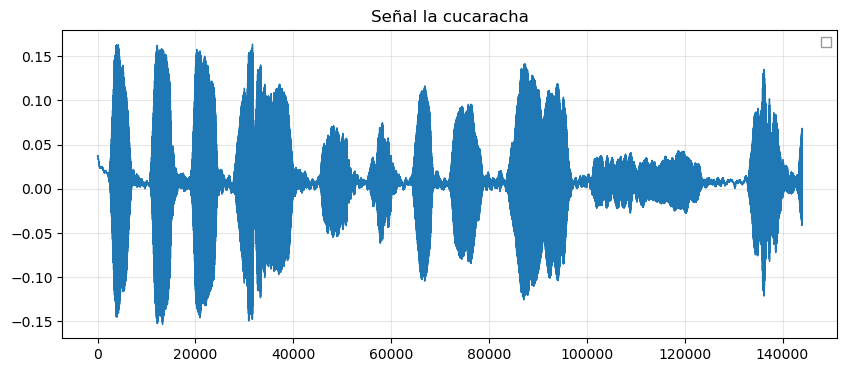

In [105]:
carpeta_script_wav = os.getcwd()

ruta_archivo_wav = os.path.join(carpeta_script_wav, 'la cucaracha.wav')

fs_audio_wav, wav_data = sio.wavfile.read(ruta_archivo_wav)


N_wav = len(wav_data)

wav_data_rotado = np.reshape(wav_data , (1, N_wav))


plt.figure(figsize=(10, 4))
plt.plot(wav_data, linewidth=1, linestyle='-', label='')
plt.title('Señal la cucaracha')
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=9)
plt.show()

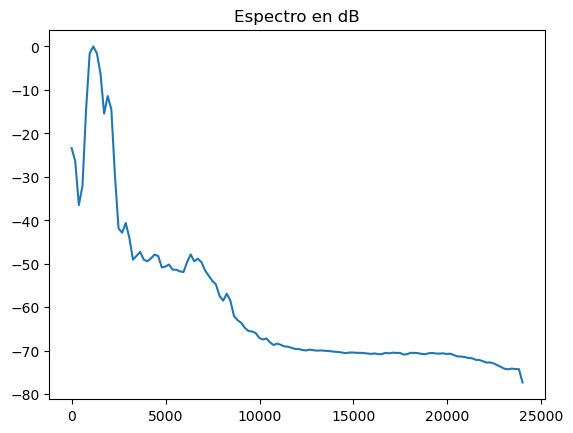

In [106]:
window_wav = sig.windows.hamming(N_wav)
nperseg_wav = 250


espectroWelch_wav = sig.welch(wav_data_rotado[0,:] - np.mean(wav_data_rotado[0,:]), fs=fs_audio_wav, nperseg=nperseg_wav)


f_wav, Pxx_wav = espectroWelch_wav

Pxx_max_wav = np.max(Pxx_wav)
Pxx_wav_escalado = Pxx_wav/Pxx_max_wav

Pxx_wav_db= 10 * np.log10(np.abs(Pxx_wav_escalado))

plt.figure()
plt.plot(f_wav, Pxx_wav_db)
plt.title('Espectro en dB')
plt.show()

In [107]:
area_wav = np.sum(Pxx_wav[f_wav <= 2080]) - np.sum(Pxx_wav[f_wav <= 760])
area_tot_wav = np.sum(Pxx_wav)
Pxx_wav_porcentaje = area_wav/area_tot_wav
print(Pxx_wav_porcentaje)

0.98383087


Para que se entienda mejor esto, graficamos el espectro de manera lineal marcando los puntos donde comienza y termina el ancho de banda.

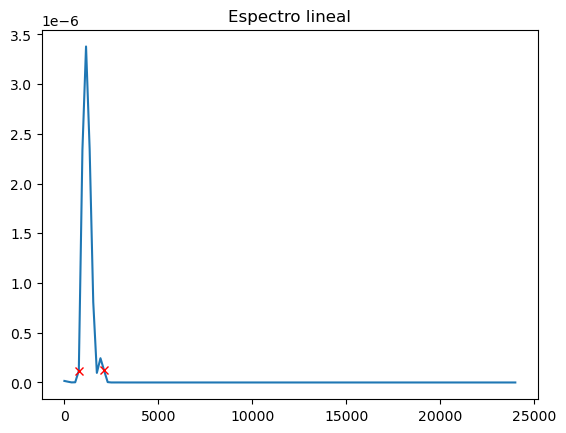

In [108]:
plt.plot(f_wav, Pxx_wav)
idx1 = np.argmin(np.abs(f_wav - 2080))
idx2 = np.argmin(np.abs(f_wav - 760))
plt.plot(f_wav[idx1], Pxx_wav[idx1], 'rx')
plt.plot(f_wav[idx2], Pxx_wav[idx2], 'rx')
plt.title('Espectro lineal')
plt.show()

## Conclusión

Con todo lo calculado en este trabajo práctico, logramos conseguir el ancho de banda de múltiples señales teniendo como punto de inicio unicamente los datos de la misma señal, llegando a conclusiones confiables con un gran apoyo en material teórico utilizado a lo largo de la materia. 

Además de esto, logramos ver de manera práctica la diferencia entre el metodo habitual con el cual calculamos un espectro (DFT), y uno de los nuevos métodos aprendidos en clase (el método de Welch).

Por último, logramos adquirir una intuición visual, basandonos en todo lo aprendido hasta el moemento en el curso, que nos permitió determinar en cada señal el valor apropiado del nperseg para poder tener una buena relación varianza-sesgo del espectro calculado.